# Elliptic++ Bitcoin Dataset: GCN vs SkipGCN

This notebook explores illicit Bitcoin transaction detection on the **Elliptic++** dataset using Graph Convolutional Networks.

## Dataset
- `txs_features.csv` — node features (txId, timestep, 166 features)
- `txs_edgelist.csv` — directed transaction edges
- `txs_classes.csv` — labels: `1`=illicit, `2`=licit, `unknown`

## Temporal splits
| Split | Timesteps |
|---|---|
| Train | 1 – 34 |
| Test | 35 – 49 |

## Architectures
1. **Standard GCN** — ablation over depth (2–4 layers) and width (64/128/256)
2. **SkipGCN** — residual skip connections at every intermediate layer, following the architecture in the Elliptic++ benchmark paper (Elmougy et al., 2023)

Primary metric: **F1 score on the illicit class** (class is rare ~10% of labeled nodes).

## 1. Environment Setup

In [15]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to your project folder
# Note: Google Drive mounts to '/content/drive/MyDrive' by default
project_path = '/content/drive/MyDrive/stat175-final-project/'

# 3. Change the current working directory
if os.path.exists(project_path):
    %cd {project_path}
    print(f"\nSuccess! Working directory set to: {os.getcwd()}")
else:
    print(f"\nError: The directory '{project_path}' was not found. Please check the spelling.")

# 4. Install dependencies from requirements.txt
if os.path.exists('requirements.txt'):
    !pip install -r requirements.txt
else:
    print("\n'requirements.txt' not found in the current directory.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/stat175-final-project

Success! Working directory set to: /content/drive/MyDrive/stat175-final-project


In [16]:
import os
import time
import warnings
from copy import deepcopy
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops, to_undirected

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

SEED = 175
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

**Option B:** mount Google Drive and set `DATA_DIR`.

In [17]:
# ── Option B: Google Drive (uncomment to use) ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/stat175-final-project/data'

FEATURES_PATH  = os.path.join(DATA_DIR, 'txs_features.csv')
CLASSES_PATH   = os.path.join(DATA_DIR, 'txs_classes.csv')
EDGELIST_PATH  = os.path.join(DATA_DIR, 'txs_edgelist.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ── Robust CSV loaders ───────────────────────────────────────────────────────

def load_features(path):
    """Load txs_features.csv with or without a header row."""
    peek = pd.read_csv(path, header=None, nrows=1)
    try:
        float(peek.iloc[0, 0])   # numeric → no header
        df = pd.read_csv(path, header=None)
        df.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(df.shape[1] - 2)]
    except (ValueError, TypeError):
        df = pd.read_csv(path)
        cols = df.columns.tolist()
        df = df.rename(columns={cols[0]: 'txId', cols[1]: 'timestep'})
    df['txId'] = df['txId'].astype(np.int64)
    df['timestep'] = df['timestep'].astype(int)
    return df


def load_classes(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    # Standardise column names
    df = df.rename(columns={df.columns[0]: 'txId', df.columns[1]: 'class'})
    df['txId'] = df['txId'].astype(np.int64)
    return df


def load_edgelist(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={df.columns[0]: 'src', df.columns[1]: 'dst'})
    df['src'] = df['src'].astype(np.int64)
    df['dst'] = df['dst'].astype(np.int64)
    return df


features_df  = load_features(FEATURES_PATH)
classes_df   = load_classes(CLASSES_PATH)
edgelist_df  = load_edgelist(EDGELIST_PATH)

print(f'Nodes (features): {len(features_df):,}')
print(f'Edges:            {len(edgelist_df):,}')
print(f'Label rows:       {len(classes_df):,}')
print(f'Feature columns:  {features_df.shape[1] - 2}')
print(f'Timestep range:   {features_df.timestep.min()} – {features_df.timestep.max()}')

Nodes (features): 203,769
Edges:            234,355
Label rows:       203,769
Feature columns:  182
Timestep range:   1 – 49


## 3. Exploratory Data Analysis

In [19]:
merged = features_df[['txId', 'timestep']].merge(classes_df, on='txId', how='left')
label_counts = merged['class'].value_counts(dropna=False)
print('Label distribution:')
print(label_counts.to_string())
print(f'\nLabeled nodes: {(merged["class"].isin(["1", "2", 1, 2])).sum():,}')
print(f'Unknown nodes: {merged["class"].isna().sum() + (merged["class"]=="unknown").sum():,}')

Label distribution:
class
3    157205
2     42019
1      4545

Labeled nodes: 46,564
Unknown nodes: 0


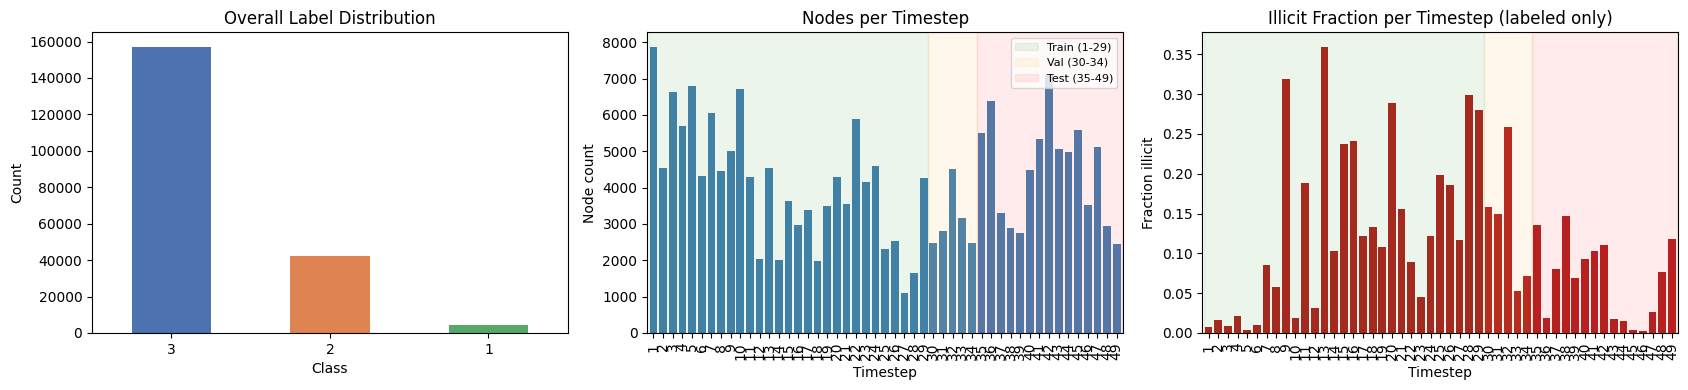

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Class distribution
ax = axes[0]
label_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Overall Label Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Nodes per timestep
ax = axes[1]
ts_counts = features_df.groupby('timestep').size()
ts_counts.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Nodes per Timestep')
ax.set_xlabel('Timestep')
ax.set_ylabel('Node count')
ax.axvspan(-0.5, 28.5,  alpha=0.08, color='green',  label='Train (1-29)')
ax.axvspan(28.5, 33.5,  alpha=0.08, color='orange', label='Val (30-34)')
ax.axvspan(33.5, 48.5,  alpha=0.08, color='red',    label='Test (35-49)')
ax.legend(fontsize=8)

# Illicit fraction per timestep (among labeled)
ax = axes[2]
merged['label_int'] = merged['class'].apply(
    lambda x: 1 if str(x) == '1' else (0 if str(x) == '2' else np.nan)
)
illicit_frac = merged.groupby('timestep')['label_int'].mean()
illicit_frac.plot(kind='bar', ax=ax, color='firebrick', width=0.8)
ax.set_title('Illicit Fraction per Timestep (labeled only)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Fraction illicit')
ax.axvspan(-0.5, 28.5,  alpha=0.08, color='green')
ax.axvspan(28.5, 33.5,  alpha=0.08, color='orange')
ax.axvspan(33.5, 48.5,  alpha=0.08, color='red')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Graph Construction

In [62]:
# ── Node mapping: txId → contiguous integer index ────────────────────────────
all_txids  = features_df['txId'].values
tx_to_idx  = {int(tx): i for i, tx in enumerate(all_txids)}
N          = len(all_txids)

# ── Feature matrix ────────────────────────────────────────────────────────────
feat_cols = [c for c in features_df.columns if c not in ('txId', 'timestep')]
X_raw     = features_df[feat_cols].values.astype(np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# Replace any NaN from zero-variance columns with 0
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

x = torch.tensor(X_scaled, dtype=torch.float)
print(f'Feature matrix: {x.shape}')
print(f'NaN count: {np.isnan(X_scaled).sum()}')

# ── Labels ────────────────────────────────────────────────────────────────────
def encode_label(v):
    s = str(v).strip()
    if s == '1':   return 1   # illicit
    if s == '2':   return 0   # licit
    return -1                 # unknown

merged = features_df[['txId', 'timestep']].merge(classes_df, on='txId', how='left')
raw_labels = merged['class'].values
labels     = np.array([encode_label(v) for v in raw_labels], dtype=np.int64)

y_all = labels.copy()
y_all[y_all == -1] = 0   # placeholder for unknown (masked out in loss)
y = torch.tensor(y_all, dtype=torch.long)

# ── Edge index ────────────────────────────────────────────────────────────────
src_raw = edgelist_df['src'].values
dst_raw = edgelist_df['dst'].values

src_idx = np.array([tx_to_idx.get(int(t), -1) for t in src_raw])
dst_idx = np.array([tx_to_idx.get(int(t), -1) for t in dst_raw])

valid   = (src_idx >= 0) & (dst_idx >= 0)
src_idx = src_idx[valid]
dst_idx = dst_idx[valid]

edge_index = torch.tensor(np.stack([src_idx, dst_idx]), dtype=torch.long)
# Make undirected and add self-loops for GCN
edge_index = to_undirected(edge_index, num_nodes=N)
edge_index, _ = add_self_loops(edge_index, num_nodes=N)

print(f'Edges (undirected + self-loops): {edge_index.shape[1]:,}')

# ── Temporal masks ────────────────────────────────────────────────────────────
timesteps   = features_df['timestep'].values
labeled     = labels >= 0

train_mask = torch.tensor(labeled & (timesteps >= 1)  & (timesteps <= 29), dtype=torch.bool)
val_mask   = torch.tensor(labeled & (timesteps >= 30) & (timesteps <= 34), dtype=torch.bool)
test_mask  = torch.tensor(labeled & (timesteps >= 35) & (timesteps <= 49), dtype=torch.bool)

print(f'Train nodes: {train_mask.sum():,}  |  Val: {val_mask.sum():,}  |  Test: {test_mask.sum():,}')

# ── Class weights for imbalanced training ─────────────────────────────────────
n_licit   = int((y[train_mask] == 0).sum())
n_illicit = int((y[train_mask] == 1).sum())
class_weight = torch.tensor([1.0, 1.0], dtype=torch.float).to(device)

print(f'Class weight: {class_weight}')

# ── Assemble PyG Data object ─────────────────────────────────────────────────
data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
).to(device)

print(f'\nData object: {data}')

Feature matrix: torch.Size([203769, 182])
NaN count: 0
Edges (undirected + self-loops): 672,479
Train nodes: 26,381  |  Val: 3,513  |  Test: 16,670
Class weight: tensor([1., 1.], device='cuda:0')

Data object: Data(x=[203769, 182], edge_index=[2, 672479], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


## 5. Model Architectures

### 5.1 Standard GCN

Vanilla GCN following Kipf & Welling (2017):
$$H^{(l+1)} = \sigma\!\left(\hat{A}\, H^{(l)}\, W^{(l)}\right)$$

We ablate over:
- **Depth**: 2, 3, 4 layers
- **Width**: 64, 128, 256 hidden units
- **Dropout**: 0.3, 0.5

In [63]:
class StandardGCN(nn.Module):
    """
    Vanilla GCN with BatchNorm and dropout.
    Ablation-friendly: configurable depth, width, dropout.
    """
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=2, dropout=0.5):
        super().__init__()
        assert num_layers >= 2, 'num_layers must be >= 2'

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = dropout

        # Input → hidden
        self.convs.append(GCNConv(in_channels, hidden_channels, cached=False))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden → hidden  (num_layers - 2 intermediate layers)
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels, cached=False))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden → output (no BN, no activation)
        self.convs.append(GCNConv(hidden_channels, out_channels, cached=False))

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)


# Quick sanity check
in_dim  = data.x.shape[1]
_model  = StandardGCN(in_dim, 128, 2, num_layers=3).to(device)
_out    = _model(data.x, data.edge_index)
print(f'StandardGCN output: {_out.shape}')  # [N, 2]
del _model, _out

StandardGCN output: torch.Size([203769, 2])


### 5.2 SkipGCN

SkipGCN adds a **residual skip connection** at every intermediate GCN layer, following the architecture evaluated in the Elliptic++ benchmark (Elmougy et al., 2023) and motivated by residual learning (He et al., 2016) applied to graphs:

$$H^{(l+1)} = \sigma\!\Bigl(\mathrm{BN}\bigl(\hat{A}\,H^{(l)}\,W^{(l)}\bigr) + \mathrm{Skip}\bigl(H^{(l)}\bigr)\Bigr)$$

where $\mathrm{Skip}$ is the identity when dimensions match, or a learned linear projection otherwise.

Skip connections:
- Alleviate **over-smoothing** in deep GCNs
- Improve **gradient flow** during training
- Allow the network to preserve local (raw-feature) information alongside neighborhood-aggregated signals

In [64]:
class SkipGCNLayer(nn.Module):
    """Single GCN layer with residual skip connection."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = GCNConv(in_channels, out_channels, cached=False)
        self.bn   = nn.BatchNorm1d(out_channels)
        # Linear projection if dimensions differ; otherwise identity
        self.skip = (
            nn.Linear(in_channels, out_channels, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, edge_index):
        h    = self.bn(self.conv(x, edge_index))
        skip = self.skip(x)
        return F.relu(h + skip)


class SkipGCN(nn.Module):
    """
    GCN with residual skip connections at every intermediate layer.

    Architecture (Elmougy et al., 2023 — Elliptic++ benchmark):
      [SkipGCNLayer] × (num_layers - 1)  →  GCNConv (classification head)

    The final layer has no skip, no BN, and no activation so that
    raw logits are returned (compatible with CrossEntropyLoss).
    """
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.5):
        super().__init__()
        assert num_layers >= 2
        self.dropout = dropout

        self.skip_layers = nn.ModuleList()

        # First skip layer: in → hidden
        self.skip_layers.append(SkipGCNLayer(in_channels, hidden_channels))

        # Intermediate skip layers: hidden → hidden
        for _ in range(num_layers - 2):
            self.skip_layers.append(SkipGCNLayer(hidden_channels, hidden_channels))

        # Classification head: hidden → out (plain GCNConv)
        self.classifier = GCNConv(hidden_channels, out_channels, cached=False)

    def forward(self, x, edge_index):
        for layer in self.skip_layers:
            x = layer(x, edge_index)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x, edge_index)


# Sanity check
_model = SkipGCN(in_dim, 128, 2, num_layers=3).to(device)
_out   = _model(data.x, data.edge_index)
print(f'SkipGCN output: {_out.shape}')   # [N, 2]
n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'SkipGCN params (hidden=128, layers=3): {n_params:,}')
del _model, _out

SkipGCN output: torch.Size([203769, 2])
SkipGCN params (hidden=128, layers=3): 64,002


## 6. Training Utilities

In [66]:
def train_step(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss   = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    pred   = logits[mask].argmax(dim=1).cpu().numpy()
    true   = data.y[mask].cpu().numpy()
    return {
        'accuracy':   accuracy_score(true, pred),
        'f1_illicit': f1_score(true, pred, pos_label=1, zero_division=0),
        'f1_macro':   f1_score(true, pred, average='macro', zero_division=0),
        'precision':  precision_score(true, pred, pos_label=1, zero_division=0),
        'recall':     recall_score(true, pred, pos_label=1, zero_division=0),
    }, pred, true


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_experiment(
    model_class, model_kwargs, data, device,
    lr=1e-3, weight_decay=5e-4,
    num_epochs=1000, patience=30,
    verbose=False
):
    model     = model_class(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weight)

    best_val_f1   = -1.0
    best_state    = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_f1': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        loss = train_step(model, data, optimizer, criterion)
        val_metrics, _, _ = evaluate(model, data, data.val_mask)
        val_f1 = val_metrics['f1_illicit']

        history['train_loss'].append(loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_metrics['accuracy'])

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_state   = deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

        if patience_cnt >= patience:
            if verbose:
                print(f'  Early stop at epoch {epoch}')
            break

        if verbose and epoch % 50 == 0:
            print(f'  Ep {epoch:3d}  loss={loss:.4f}  val_f1={val_f1:.4f}')

    # Load best model and evaluate on both val and test
    model.load_state_dict(best_state)
    test_metrics, test_pred, test_true = evaluate(model, data, data.test_mask)
    val_metrics, _, _ = evaluate(model, data, data.val_mask)

    return {
        'model':         model,
        'params':        count_params(model),
        'train_time':    time.time() - t0,
        'best_epoch':    epoch - patience_cnt,
        'val_f1':        val_metrics['f1_illicit'],
        'val_f1_macro':  val_metrics['f1_macro'],
        'val_acc':       val_metrics['accuracy'],
        'test_f1':       test_metrics['f1_illicit'],
        'test_f1_macro': test_metrics['f1_macro'],
        'test_acc':      test_metrics['accuracy'],
        'test_prec':     test_metrics['precision'],
        'test_recall':   test_metrics['recall'],
        'history':       history,
        'test_pred':     test_pred,
        'test_true':     test_true,
    }

## 7. Standard GCN — Ablation Study

Grid search over:
- `num_layers` ∈ {2, 3, 4}
- `hidden_channels` ∈ {64, 128, 256}
- `dropout` ∈ {0.3, 0.5}

In [68]:
gcn_grid = {
    'num_layers':       [2, 3, 4],
    'hidden_channels':  [64, 128, 256],
    'dropout':          [0.3, 0.5],
}

gcn_results = []

configs = list(product(
    gcn_grid['num_layers'],
    gcn_grid['hidden_channels'],
    gcn_grid['dropout'],
))
print(f'Running {len(configs)} Standard GCN configurations...\n')

for i, (nlayers, hidden, drop) in enumerate(configs, 1):
    tag = f'L={nlayers} H={hidden} do={drop}'
    print(f'[{i:2d}/{len(configs)}] {tag}', end='  ')

    result = run_experiment(
        model_class  = StandardGCN,
        model_kwargs = dict(
            in_channels     = in_dim,
            hidden_channels = hidden,
            out_channels    = 2,
            num_layers      = nlayers,
            dropout         = drop,
        ),
        data         = data,
        device       = device,
        num_epochs   = 1000,
        verbose      = True,
    )

    result['config'] = tag
    result['num_layers'] = nlayers
    result['hidden']     = hidden
    result['dropout']    = drop
    gcn_results.append(result)

    print(f'val_f1={result["val_f1"]:.4f}  '
      f'test_f1={result["test_f1"]:.4f}  '
      f'test_acc={result["test_acc"]:.4f}  '
      f'({result["train_time"]:.0f}s)')

print('\nDone.')

Running 18 Standard GCN configurations...

[ 1/18] L=2 H=64 do=0.3    Ep  50  loss=0.1667  val_f1=0.5828
  Ep 100  loss=0.1385  val_f1=0.6380
  Ep 150  loss=0.1237  val_f1=0.6871
  Ep 200  loss=0.1116  val_f1=0.7098
  Ep 250  loss=0.1024  val_f1=0.7262
  Ep 300  loss=0.0946  val_f1=0.7211
  Ep 350  loss=0.0868  val_f1=0.7406
  Ep 400  loss=0.0826  val_f1=0.7601
  Ep 450  loss=0.0779  val_f1=0.7733
  Ep 500  loss=0.0733  val_f1=0.7944
  Ep 550  loss=0.0706  val_f1=0.8075
  Early stop at epoch 599
val_f1=0.8110  test_f1=0.3816  test_acc=0.8542  (30s)
[ 2/18] L=2 H=64 do=0.5    Ep  50  loss=0.1723  val_f1=0.5966
  Ep 100  loss=0.1419  val_f1=0.6459
  Ep 150  loss=0.1284  val_f1=0.6741
  Ep 200  loss=0.1173  val_f1=0.6885
  Ep 250  loss=0.1088  val_f1=0.7137
  Ep 300  loss=0.1020  val_f1=0.7219
  Ep 350  loss=0.0962  val_f1=0.7429
  Ep 400  loss=0.0913  val_f1=0.7604
  Ep 450  loss=0.0884  val_f1=0.7737
  Ep 500  loss=0.0819  val_f1=0.7781
  Early stop at epoch 509
val_f1=0.7878  test_f1=0

In [69]:
# ── Results table ─────────────────────────────────────────────────────────────
gcn_table = pd.DataFrame([
    {
        'Config':         r['config'],
        '# Params':       f"{r['params']:,}",
        'Val F1 (ill.)':  f"{r['val_f1']:.4f}",
        'Test F1 (ill.)': f"{r['test_f1']:.4f}",
        'Test F1 macro':  f"{r['test_f1_macro']:.4f}",
        'Test Acc':       f"{r['test_acc']:.4f}",
        'Precision':      f"{r['test_prec']:.4f}",
        'Recall':         f"{r['test_recall']:.4f}",
        'Best Epoch':     r['best_epoch'],
    }
    for r in gcn_results
])
gcn_table = gcn_table.sort_values('Test F1 (ill.)', ascending=False)
print(tabulate(gcn_table, headers='keys', tablefmt='github', showindex=False))

| Config           | # Params   |   Val F1 (ill.) |   Test F1 (ill.) |   Test F1 macro |   Test Acc |   Precision |   Recall |   Best Epoch |
|------------------|------------|-----------------|------------------|-----------------|------------|-------------|----------|--------------|
| L=2 H=128 do=0.5 | 23,938     |          0.7966 |           0.4122 |          0.6699 |     0.8711 |      0.2929 |   0.6953 |          472 |
| L=2 H=256 do=0.3 | 47,874     |          0.7625 |           0.3946 |          0.6612 |     0.871  |      0.2838 |   0.6473 |           62 |
| L=2 H=64 do=0.3  | 11,970     |          0.811  |           0.3816 |          0.6495 |     0.8542 |      0.2633 |   0.6925 |          569 |
| L=2 H=256 do=0.5 | 47,874     |          0.7425 |           0.3482 |          0.6264 |     0.8336 |      0.2335 |   0.6842 |           81 |
| L=2 H=64 do=0.5  | 11,970     |          0.7878 |           0.3321 |          0.6124 |     0.8152 |      0.217  |   0.7073 |          479 |
| L=2 

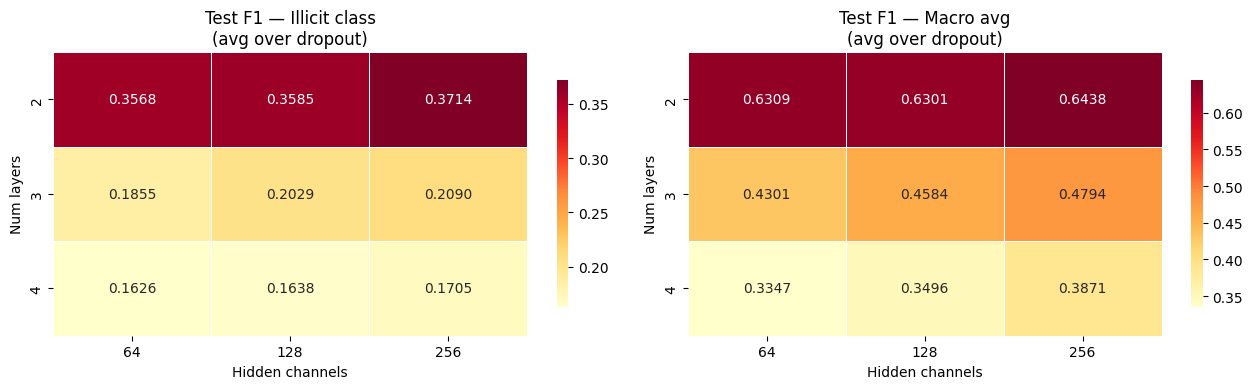

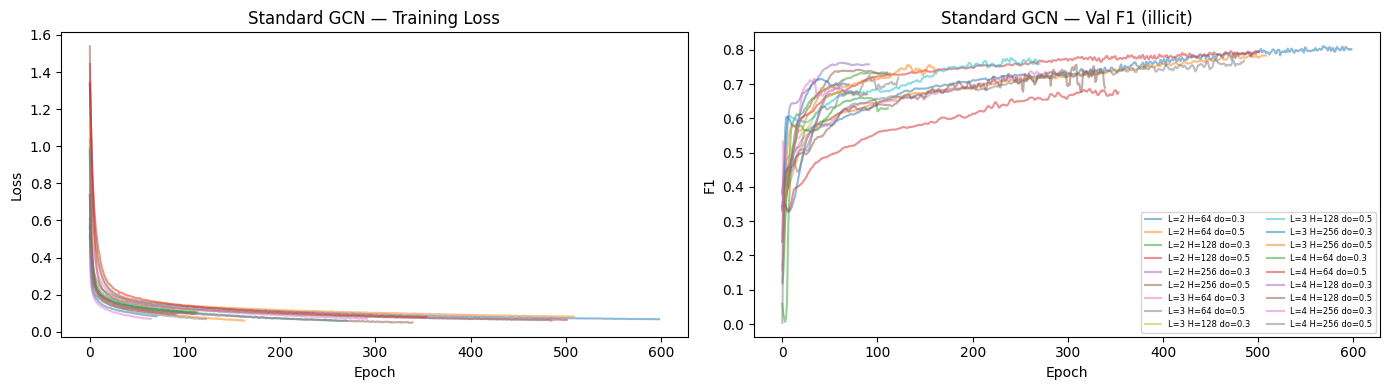

In [70]:
# ── Heatmap: Test F1 (illicit) by depth × width (averaged over dropout) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ['test_f1', 'test_f1_macro'],
    ['Test F1 — Illicit class', 'Test F1 — Macro avg']
):
    pivot = pd.DataFrame(gcn_results)
    pivot = pivot.groupby(['num_layers', 'hidden'])[metric].mean().unstack()
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title + '\n(avg over dropout)')
    ax.set_xlabel('Hidden channels')
    ax.set_ylabel('Num layers')

plt.tight_layout()
plt.savefig('gcn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves for all GCN configs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for r in gcn_results:
    axes[0].plot(r['history']['train_loss'], alpha=0.5, label=r['config'])
    axes[1].plot(r['history']['val_f1'],     alpha=0.5, label=r['config'])

axes[0].set_title('Standard GCN — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Standard GCN — Val F1 (illicit)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig('gcn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SkipGCN — Experiments

We match the best standard-GCN hidden width and test the same depth range so the comparison is fair.  
Additional dropout values are explored to account for the stronger regularisation from skip connections.

In [71]:
skip_grid = {
    'num_layers':       [2, 3, 4],
    'hidden_channels':  [64, 128, 256],
    'dropout':          [0.3, 0.5],
}

skip_results = []

configs = list(product(
    skip_grid['num_layers'],
    skip_grid['hidden_channels'],
    skip_grid['dropout'],
))
print(f'Running {len(configs)} SkipGCN configurations...\n')

for i, (nlayers, hidden, drop) in enumerate(configs, 1):
    tag = f'L={nlayers} H={hidden} do={drop}'
    print(f'[{i:2d}/{len(configs)}] {tag}', end='  ')

    result = run_experiment(
        model_class  = SkipGCN,
        model_kwargs = dict(
            in_channels     = in_dim,
            hidden_channels = hidden,
            out_channels    = 2,
            num_layers      = nlayers,
            dropout         = drop,
        ),
        data         = data,
        device       = device,
        num_epochs   = 300,
        patience     = 30,
        verbose      = False,
    )

    result['config']     = tag
    result['num_layers'] = nlayers
    result['hidden']     = hidden
    result['dropout']    = drop
    skip_results.append(result)

    print(f'val_f1={result["val_f1"]:.4f}  '
          f'test_f1={result["test_f1"]:.4f}  '
          f'test_acc={result["test_acc"]:.4f}  '
          f'({result["train_time"]:.0f}s)')

print('\nDone.')

Running 18 SkipGCN configurations...

[ 1/18] L=2 H=64 do=0.3  val_f1=0.8377  test_f1=0.4428  test_acc=0.8858  (13s)
[ 2/18] L=2 H=64 do=0.5  val_f1=0.8276  test_f1=0.4166  test_acc=0.8720  (13s)
[ 3/18] L=2 H=128 do=0.3  val_f1=0.8482  test_f1=0.5137  test_acc=0.9172  (22s)
[ 4/18] L=2 H=128 do=0.5  val_f1=0.8392  test_f1=0.4701  test_acc=0.9022  (17s)
[ 5/18] L=2 H=256 do=0.3  val_f1=0.8273  test_f1=0.4739  test_acc=0.9058  (21s)
[ 6/18] L=2 H=256 do=0.5  val_f1=0.8341  test_f1=0.4594  test_acc=0.8971  (28s)
[ 7/18] L=3 H=64 do=0.3  val_f1=0.7968  test_f1=0.2419  test_acc=0.6861  (22s)
[ 8/18] L=3 H=64 do=0.5  val_f1=0.7450  test_f1=0.3045  test_acc=0.7789  (8s)
[ 9/18] L=3 H=128 do=0.3  val_f1=0.8562  test_f1=0.3851  test_acc=0.8477  (27s)
[10/18] L=3 H=128 do=0.5  val_f1=0.8235  test_f1=0.2916  test_acc=0.7630  (38s)
[11/18] L=3 H=256 do=0.3  val_f1=0.8443  test_f1=0.5209  test_acc=0.9167  (39s)
[12/18] L=3 H=256 do=0.5  val_f1=0.8443  test_f1=0.3938  test_acc=0.8536  (54s)
[13/18]

In [72]:
skip_table = pd.DataFrame([
    {
        'Config':         r['config'],
        '# Params':       f"{r['params']:,}",
        'Val F1 (ill.)':  f"{r['val_f1']:.4f}",
        'Test F1 (ill.)': f"{r['test_f1']:.4f}",
        'Test F1 macro':  f"{r['test_f1_macro']:.4f}",
        'Test Acc':       f"{r['test_acc']:.4f}",
        'Precision':      f"{r['test_prec']:.4f}",
        'Recall':         f"{r['test_recall']:.4f}",
        'Best Epoch':     r['best_epoch'],
    }
    for r in skip_results
])
skip_table = skip_table.sort_values('Test F1 (ill.)', ascending=False)
print(tabulate(skip_table, headers='keys', tablefmt='github', showindex=False))

| Config           | # Params   |   Val F1 (ill.) |   Test F1 (ill.) |   Test F1 macro |   Test Acc |   Precision |   Recall |   Best Epoch |
|------------------|------------|-----------------|------------------|-----------------|------------|-------------|----------|--------------|
| L=3 H=256 do=0.3 | 160,770    |          0.8443 |           0.5209 |          0.7376 |     0.9167 |      0.4157 |   0.6971 |          127 |
| L=2 H=128 do=0.3 | 47,234     |          0.8482 |           0.5137 |          0.7342 |     0.9172 |      0.4154 |   0.6731 |          298 |
| L=2 H=256 do=0.3 | 94,466     |          0.8273 |           0.4739 |          0.7111 |     0.9058 |      0.3719 |   0.6528 |          127 |
| L=2 H=128 do=0.5 | 47,234     |          0.8392 |           0.4701 |          0.7081 |     0.9022 |      0.3628 |   0.6676 |          204 |
| L=2 H=256 do=0.5 | 94,466     |          0.8341 |           0.4594 |          0.7012 |     0.8971 |      0.3486 |   0.6731 |          176 |
| L=2 

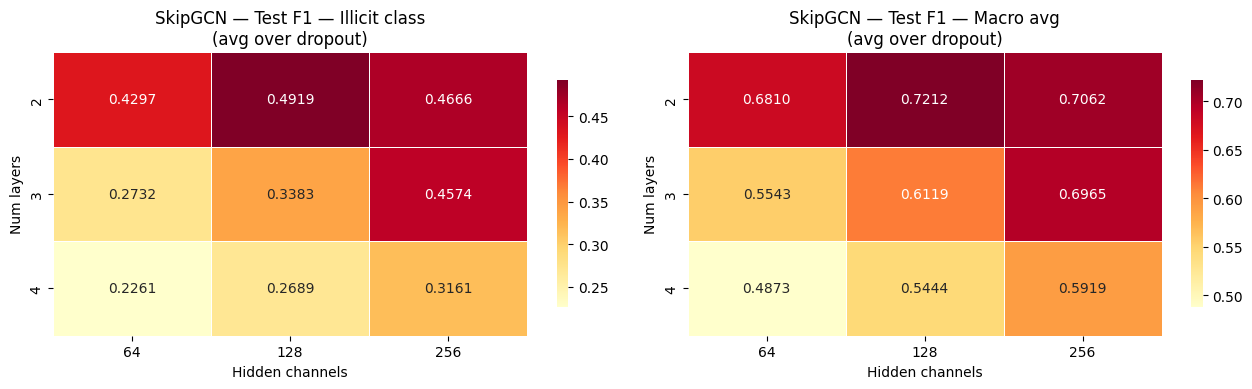

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ['test_f1', 'test_f1_macro'],
    ['Test F1 — Illicit class', 'Test F1 — Macro avg']
):
    pivot = pd.DataFrame(skip_results)
    pivot = pivot.groupby(['num_layers', 'hidden'])[metric].mean().unstack()
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    ax.set_title('SkipGCN — ' + title + '\n(avg over dropout)')
    ax.set_xlabel('Hidden channels')
    ax.set_ylabel('Num layers')

plt.tight_layout()
plt.savefig('skip_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Comparison: Standard GCN vs SkipGCN

In [75]:
# Best configuration of each architecture (by val F1)
best_gcn  = max(gcn_results,  key=lambda r: r['test_f1'])
best_skip = max(skip_results, key=lambda r: r['test_f1'])

comparison = pd.DataFrame([
    {'Model': 'Standard GCN', 'Config': best_gcn['config'],
     '# Params': best_gcn['params'],
     'Val F1 (ill.)': best_gcn['val_f1'],
     'Test F1 (ill.)': best_gcn['test_f1'],
     'Test F1 macro':  best_gcn['test_f1_macro'],
     'Test Acc': best_gcn['test_acc'],
     'Precision': best_gcn['test_prec'],
     'Recall': best_gcn['test_recall']},
    {'Model': 'SkipGCN', 'Config': best_skip['config'],
     '# Params': best_skip['params'],
     'Val F1 (ill.)': best_skip['val_f1'],
     'Test F1 (ill.)': best_skip['test_f1'],
     'Test F1 macro':  best_skip['test_f1_macro'],
     'Test Acc': best_skip['test_acc'],
     'Precision': best_skip['test_prec'],
     'Recall': best_skip['test_recall']},
])
print(tabulate(comparison.round(4), headers='keys', tablefmt='github', showindex=False))

| Model        | Config           |   # Params |   Val F1 (ill.) |   Test F1 (ill.) |   Test F1 macro |   Test Acc |   Precision |   Recall |
|--------------|------------------|------------|-----------------|------------------|-----------------|------------|-------------|----------|
| Standard GCN | L=2 H=128 do=0.5 |      23938 |          0.7966 |           0.4122 |          0.6699 |     0.8711 |      0.2929 |   0.6953 |
| SkipGCN      | L=3 H=256 do=0.3 |     160770 |          0.8443 |           0.5209 |          0.7376 |     0.9167 |      0.4157 |   0.6971 |


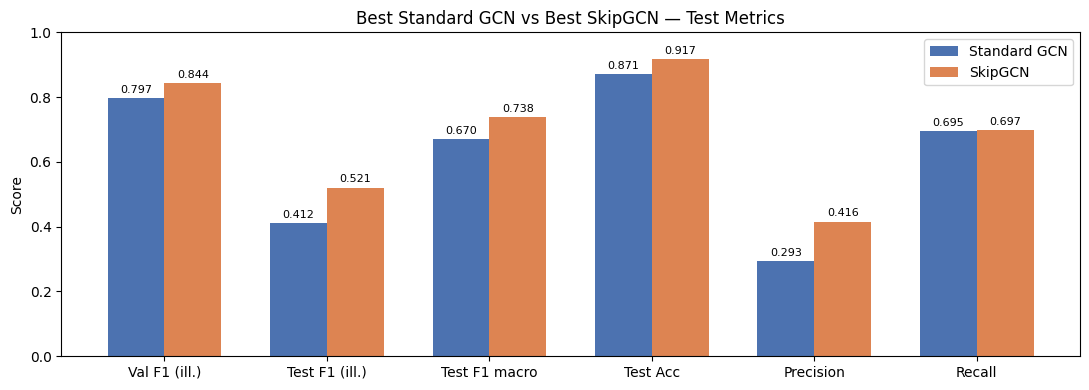

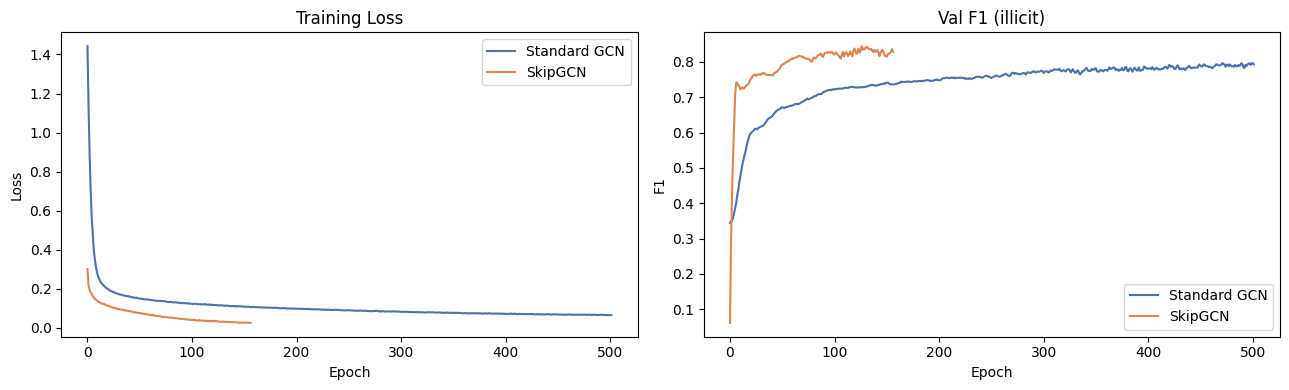

In [76]:
# ── Side-by-side metric bar chart ─────────────────────────────────────────────
metrics   = ['Val F1 (ill.)', 'Test F1 (ill.)', 'Test F1 macro', 'Test Acc', 'Precision', 'Recall']
gcn_vals  = comparison[comparison['Model'] == 'Standard GCN'][metrics].values[0].astype(float)
skip_vals = comparison[comparison['Model'] == 'SkipGCN'][metrics].values[0].astype(float)

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, gcn_vals,  w, label='Standard GCN', color='#4C72B0')
ax.bar(x + w/2, skip_vals, w, label='SkipGCN',       color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Best Standard GCN vs Best SkipGCN — Test Metrics')
ax.legend()
for xi, (g, s) in enumerate(zip(gcn_vals, skip_vals)):
    ax.text(xi - w/2, g + 0.01, f'{g:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(xi + w/2, s + 0.01, f'{s:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves (best of each) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r, label, color in [
    (best_gcn,  'Standard GCN', '#4C72B0'),
    (best_skip, 'SkipGCN',       '#DD8452')
]:
    axes[0].plot(r['history']['train_loss'], label=label, color=color)
    axes[1].plot(r['history']['val_f1'],     label=label, color=color)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Val F1 (illicit)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

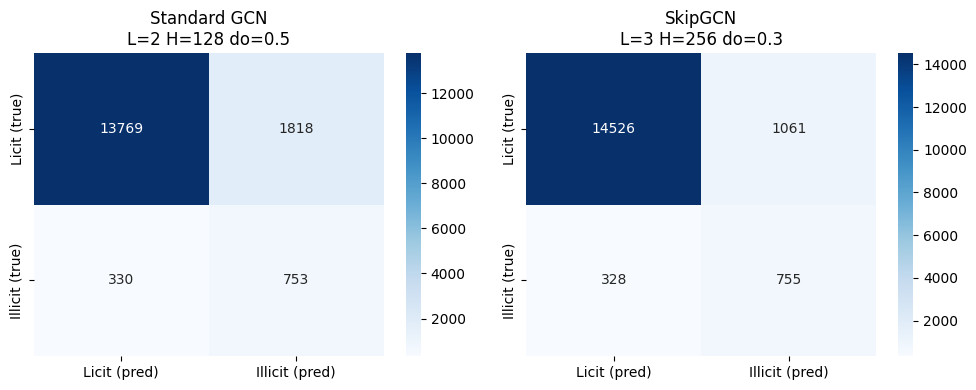

In [77]:
# ── Confusion matrices on test set ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result, title in [
    (axes[0], best_gcn,  'Standard GCN'),
    (axes[1], best_skip, 'SkipGCN'),
]:
    cm = confusion_matrix(result['test_true'], result['test_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Licit (pred)', 'Illicit (pred)'],
        yticklabels=['Licit (true)', 'Illicit (true)'],
    )
    ax.set_title(f'{title}\n{result["config"]}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# ── Classification report ─────────────────────────────────────────────────────
for result, title in [(best_gcn, 'Standard GCN'), (best_skip, 'SkipGCN')]:
    print(f'\n=== {title} ({result["config"]}) ===')
    print(classification_report(
        result['test_true'], result['test_pred'],
        target_names=['licit', 'illicit'], digits=4
    ))


=== Standard GCN (L=2 H=128 do=0.5) ===
              precision    recall  f1-score   support

       licit     0.9766    0.8834    0.9276     15587
     illicit     0.2929    0.6953    0.4122      1083

    accuracy                         0.8711     16670
   macro avg     0.6347    0.7893    0.6699     16670
weighted avg     0.9322    0.8711    0.8942     16670


=== SkipGCN (L=3 H=256 do=0.3) ===
              precision    recall  f1-score   support

       licit     0.9779    0.9319    0.9544     15587
     illicit     0.4157    0.6971    0.5209      1083

    accuracy                         0.9167     16670
   macro avg     0.6968    0.8145    0.7376     16670
weighted avg     0.9414    0.9167    0.9262     16670



## 10. Per-Timestep Analysis

Inspect how F1 (illicit) evolves over the 15 test timesteps (35–49).

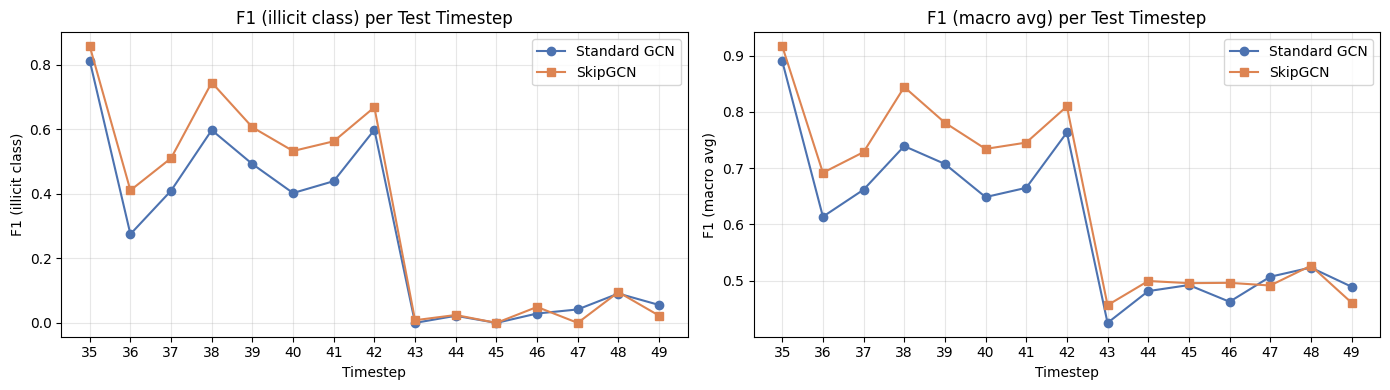


Per-timestep results — Standard GCN:
 timestep  n_nodes  f1_illicit  f1_macro  accuracy
       35     1341      0.8122    0.8899    0.9448
       36     1708      0.2749    0.6136    0.9104
       37      498      0.4094    0.6616    0.8494
       38      756      0.5971    0.7390    0.8161
       39     1183      0.4920    0.7073    0.8656
       40     1211      0.4022    0.6484    0.8208
       41     1132      0.4390    0.6649    0.8171
       42     2154      0.5982    0.7632    0.8784
       43     1370      0.0000    0.4249    0.7387
       44     1591      0.0220    0.4813    0.8881
       45     1221      0.0000    0.4921    0.9689
       46      712      0.0290    0.4624    0.8118
       47      846      0.0417    0.5068    0.9456
       48      471      0.0909    0.5232    0.9151
       49      476      0.0556    0.4891    0.8571

Per-timestep results — SkipGCN:
 timestep  n_nodes  f1_illicit  f1_macro  accuracy
       35     1341      0.8571    0.9166    0.9590
       36  

In [79]:
def per_timestep_f1(result_dict, data, timesteps_arr, labels_arr, split='test'):
    """
    Evaluate the best saved model at each timestep in the test set.
    Returns a DataFrame with columns [timestep, f1_illicit, f1_macro, accuracy].
    """
    model = result_dict['model']
    model.eval()

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds  = logits.argmax(dim=1).cpu().numpy()

    rows = []
    ts_range = range(35, 50) if split == 'test' else range(30, 35)

    for ts in ts_range:
        mask = (timesteps_arr == ts) & (labels_arr >= 0)
        if mask.sum() == 0:
            continue
        y_true = labels_arr[mask]
        y_pred = preds[mask]
        rows.append({
            'timestep':   ts,
            'n_nodes':    mask.sum(),
            'f1_illicit': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            'f1_macro':   f1_score(y_true, y_pred, average='macro', zero_division=0),
            'accuracy':   accuracy_score(y_true, y_pred),
        })
    return pd.DataFrame(rows)


ts_arr = features_df['timestep'].values
lab_arr = labels   # numpy int64 array built earlier

ts_gcn  = per_timestep_f1(best_gcn,  data, ts_arr, lab_arr)
ts_skip = per_timestep_f1(best_skip, data, ts_arr, lab_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in [
    (axes[0], 'f1_illicit', 'F1 (illicit class)'),
    (axes[1], 'f1_macro',   'F1 (macro avg)'),
]:
    ax.plot(ts_gcn['timestep'],  ts_gcn[metric],  marker='o', label='Standard GCN', color='#4C72B0')
    ax.plot(ts_skip['timestep'], ts_skip[metric], marker='s', label='SkipGCN',       color='#DD8452')
    ax.set_xlabel('Timestep')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Test Timestep')
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('per_timestep.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-timestep results — Standard GCN:')
print(ts_gcn.round(4).to_string(index=False))
print('\nPer-timestep results — SkipGCN:')
print(ts_skip.round(4).to_string(index=False))

## 11. Full Ablation Summary

In [80]:
def build_summary(results, arch_name):
    rows = []
    for r in results:
        rows.append({
            'Arch':           arch_name,
            'Config':         r['config'],
            '# Params':       r['params'],
            'Val F1':         round(r['val_f1'], 4),
            'Test F1 (ill.)': round(r['test_f1'], 4),
            'Test F1 macro':  round(r['test_f1_macro'], 4),
            'Test Acc':       round(r['test_acc'], 4),
            'Precision':      round(r['test_prec'], 4),
            'Recall':         round(r['test_recall'], 4),
            'Best Epoch':     r['best_epoch'],
        })
    return pd.DataFrame(rows)

summary_gcn  = build_summary(gcn_results,  'StandardGCN')
summary_skip = build_summary(skip_results, 'SkipGCN')
summary_all  = pd.concat([summary_gcn, summary_skip], ignore_index=True)
summary_all  = summary_all.sort_values('Test F1 (ill.)', ascending=False)

print('Top-10 configurations overall:')
print(tabulate(summary_all.head(10), headers='keys', tablefmt='github', showindex=False))

# Save to CSV
summary_all.to_csv('ablation_results.csv', index=False)
print('\nFull ablation saved to ablation_results.csv')

Top-10 configurations overall:
| Arch        | Config           |   # Params |   Val F1 |   Test F1 (ill.) |   Test F1 macro |   Test Acc |   Precision |   Recall |   Best Epoch |
|-------------|------------------|------------|----------|------------------|-----------------|------------|-------------|----------|--------------|
| SkipGCN     | L=3 H=256 do=0.3 |     160770 |   0.8443 |           0.5209 |          0.7376 |     0.9167 |      0.4157 |   0.6971 |          127 |
| SkipGCN     | L=2 H=128 do=0.3 |      47234 |   0.8482 |           0.5137 |          0.7342 |     0.9172 |      0.4154 |   0.6731 |          298 |
| SkipGCN     | L=2 H=256 do=0.3 |      94466 |   0.8273 |           0.4739 |          0.7111 |     0.9058 |      0.3719 |   0.6528 |          127 |
| SkipGCN     | L=2 H=128 do=0.5 |      47234 |   0.8392 |           0.4701 |          0.7081 |     0.9022 |      0.3628 |   0.6676 |          204 |
| SkipGCN     | L=2 H=256 do=0.5 |      94466 |   0.8341 |           0.4594

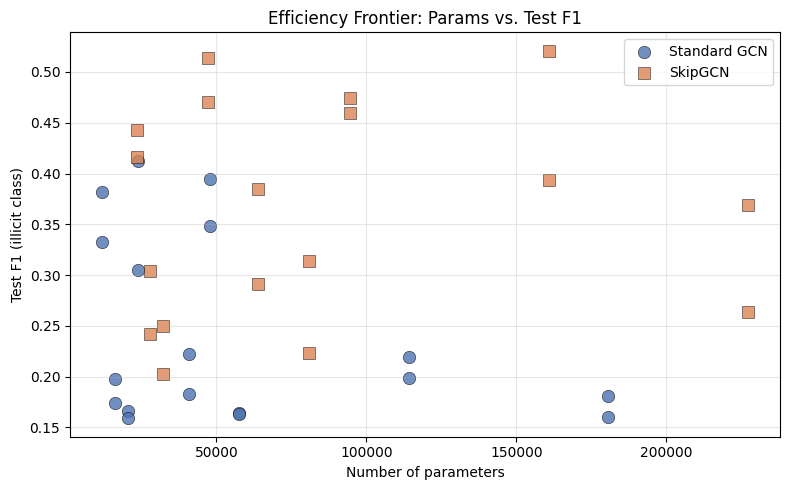

In [81]:
# ── Scatter: param count vs test F1 for both architectures ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for results, label, marker, color in [
    (gcn_results,  'Standard GCN', 'o', '#4C72B0'),
    (skip_results, 'SkipGCN',       's', '#DD8452'),
]:
    params  = [r['params'] for r in results]
    test_f1 = [r['test_f1'] for r in results]
    ax.scatter(params, test_f1, label=label, marker=marker, color=color,
               alpha=0.8, s=80, edgecolors='k', linewidths=0.4)

ax.set_xlabel('Number of parameters')
ax.set_ylabel('Test F1 (illicit class)')
ax.set_title('Efficiency Frontier: Params vs. Test F1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('params_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()